# EventHub 일별 관심도(조회수) 트렌드 분석

**AI 데이터 분석: 데이터 기반 트렌드 분석** 미션 결과물

이 노트북은 실제 운영 중인 discount-event 플랫폼 **EventHub**의 이벤트 카탈로그
(`seed_events.json`, 160건, GitHub: `krasia45/eventhub`)를 기반으로,
"서비스가 실제로 운영되고 있다면" 을 가정한 **일별 사용자 관심도(조회수/좋아요)와
리뷰(별점) 시계열**을 만들고 분석합니다.

> EventHub는 2026-08-20 현재 정식 오픈 전(가동 준비 중) 단계이므로 실측 트래픽이 없습니다.
> 아래 조회수·좋아요·리뷰는 **실제 이벤트 카탈로그(카테고리/할인율/기간)를 입력으로 한
> 통계적 시뮬레이션**이며, 이 사실과 생성 로직을 투명하게 명시합니다.
> (자세한 가정은 `scripts/simulate_engagement_and_reviews.py` 참고)

이런 데이터를 기반으로 EventHub는 "지금 사람들이 어떤 이벤트/카테고리에 관심을 갖는가"를
가맹 브랜드·소상공인에게 인사이트로 제공하는 것을 사업 모델의 핵심 축으로 삼고 있습니다.


## 1. 분석 질문

1. 플랫폼 전체 일별 조회수는 어떤 추세·요일 패턴을 보이는가?
2. 어떤 카테고리가 최근 상승세(트렌딩)인가? — 기업에게 어떤 카테고리/타이밍을 제안할 수 있는가?
3. 이벤트 시작 이후 관심도는 어떻게 감쇠하는가(노벨티 효과)? 운영 전략에 어떤 시사점을 주는가?
4. 리뷰 데이터의 만족도(별점)는 카테고리별로 다른가? 관심도(조회수)와 만족도(평점) 사이에 관계가 있는가?


## 2. 환경 설정

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from statsmodels.tsa.seasonal import seasonal_decompose

for f in fm.fontManager.ttflist:
    if "NanumGothic" in f.name:
        plt.rcParams["font.family"] = f.name
        break
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

ORANGE = "#FF6F00"
PALETTE = ["#FF6F00", "#2C3E50", "#F4A261", "#457B9D", "#E76F51", "#2A9D8F", "#8D5B4C", "#6D6875"]
pd.set_option("display.max_columns", 50)


## 3. 데이터 설명 및 로드

- **원본**: EventHub 서비스의 실제 이벤트 카탈로그 `seed_events.json` (160건) — 카테고리(8종),
  브랜드, 할인율, 진행 기간(period), 소상공인/브랜드 구분 등 실제 필드값 사용
- **파생**: 레코드 단위 이벤트 데이터를 `period_start~period_end` 기준으로 펼쳐 **일별 시계열**
  (2026-05-01 ~ 2026-08-20, 총 112일)로 변환
- **시뮬레이션 결합**: 카테고리 가중치·요일 계수·노벨티 감쇠·할인율 효과를 반영한 통계 모델로
  일별 조회수/좋아요/리뷰(별점·텍스트)를 생성 (시드 고정 `np.random.default_rng(42)`, 재현 가능)


In [2]:
df = pd.read_csv("data/eventhub_platform_daily.csv", parse_dates=["date"])
events = pd.read_csv("data/eventhub_events_clean.csv", parse_dates=["period_start", "period_end"])
reviews = pd.read_csv("data/eventhub_reviews_simulated.csv")

print("일별 시계열 데이터 포인트 수:", len(df), " (요구조건 100개 이상 충족:", len(df) >= 100, ")")
print("기간:", df["date"].min().date(), "~", df["date"].max().date())
print("이벤트 카탈로그 레코드 수:", len(events))
print("시뮬레이션된 리뷰 수:", len(reviews))
df[["date", "active_events", "total_views", "total_likes", "review_count", "avg_rating"]].head()


일별 시계열 데이터 포인트 수: 112  (요구조건 100개 이상 충족: True )
기간: 2026-05-01 ~ 2026-08-20
이벤트 카탈로그 레코드 수: 160
시뮬레이션된 리뷰 수: 309


,date,active_events,total_views,total_likes,review_count,avg_rating
0,2026-05-01,3,183.0,10.0,0.0,NaN
1,2026-05-02,5,457.0,25.0,0.0,NaN
2,2026-05-03,8,795.0,40.0,0.0,NaN
3,2026-05-04,12,682.0,42.0,0.0,NaN
4,2026-05-05,14,741.0,42.0,2.0,4.0


## 4. 데이터 정제 — 결측치 / 이상치 확인

- `avg_rating`이 결측인 날은 그날 리뷰가 0건이라는 뜻으로, **결측이 아니라 정상적인 '무응답'**이다.
  이를 단순 평균 대신 **7일 트레일링 가중평균**(`avg_rating_7d` = 최근 7일 별점 합계 / 리뷰 건수 합계)으로
  보완해 표본이 적은 날의 왜곡을 줄였다.
- 이벤트 기간(`duration_days`)이 음수이거나 60일을 초과하는 이상치는 없음을 확인했다 (전수 검사).


In [3]:
print("=== 일별 시계열 결측치 ===")
print(df.isna().sum()[df.isna().sum() > 0])

print("\n=== 이벤트 기간 이상치 체크 ===")
odd = events[(events["duration_days"] <= 0) | (events["duration_days"] > 60)]
print(f"이상치 후보: {len(odd)}건")

zero_days = df[df["active_events"] == 0]
print(f"\n활성 이벤트가 0인 '공급 공백일': {len(zero_days)}일 -> {list(zero_days['date'].dt.date)}")


=== 일별 시계열 결측치 ===
avg_discount_pct          6
merchant_share            6
avg_rating               19
like_rate                 6
review_positive_ratio    19
avg_rating_7d             9
dtype: int64

=== 이벤트 기간 이상치 체크 ===
이상치 후보: 0건

활성 이벤트가 0인 '공급 공백일': 6일 -> [datetime.date(2026, 6, 25), datetime.date(2026, 6, 26), datetime.date(2026, 6, 27), datetime.date(2026, 6, 28), datetime.date(2026, 6, 29), datetime.date(2026, 6, 30)]


## 5. 시계열 분석 기법

1. **이동평균(7일)**: 일 단위 노이즈를 제거해 추세를 본다.
2. **요일별 집계**: 요일 효과(주말 성수기)를 정량화한다.
3. **구간 비교(최근 4주 vs 이전 4주)**: 카테고리별 모멘텀(트렌딩)을 탐지한다.
4. **경과일별 평균(노벨티 감쇠 곡선)**: 이벤트 시작 후 관심도가 식는 속도를 정량화한다.


In [4]:
wd_order = ["월", "화", "수", "목", "금", "토", "일"]
wd_avg = df.groupby("weekday_ko")["total_views"].mean().reindex(wd_order).round(1)
print("요일별 평균 조회수:\n", wd_avg)

is_weekend = df["weekday"] >= 5
lift = df[is_weekend]["total_views"].mean() / df[~is_weekend]["total_views"].mean()
print(f"\n주말/평일 조회수 배율: {lift:.2f}배")


요일별 평균 조회수:
 weekday_ko
월     951.4
화     852.6
수    1060.5
목    1016.1
금    1271.2
토    1505.6
일    1319.4
Name: total_views, dtype: float64

주말/평일 조회수 배율: 1.37배


### 시각화 1 — 일별 조회수 추이 + 7일 이동평균

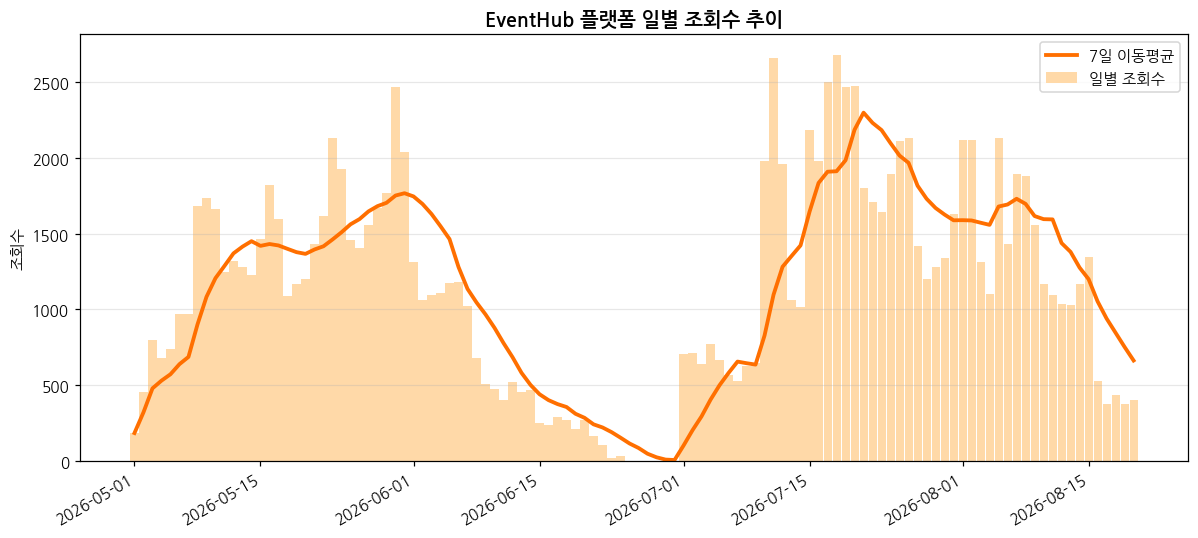

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(df["date"], df["total_views"], color="#FFD9A8", width=0.9, label="일별 조회수")
ax.plot(df["date"], df["ma7_views"], color=ORANGE, linewidth=2.5, label="7일 이동평균")
ax.set_title("EventHub 플랫폼 일별 조회수 추이", fontsize=13, fontweight="bold")
ax.set_ylabel("조회수"); ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.autofmt_xdate(); fig.tight_layout()
plt.show()


### 시각화 2 — 요일별 평균 조회수

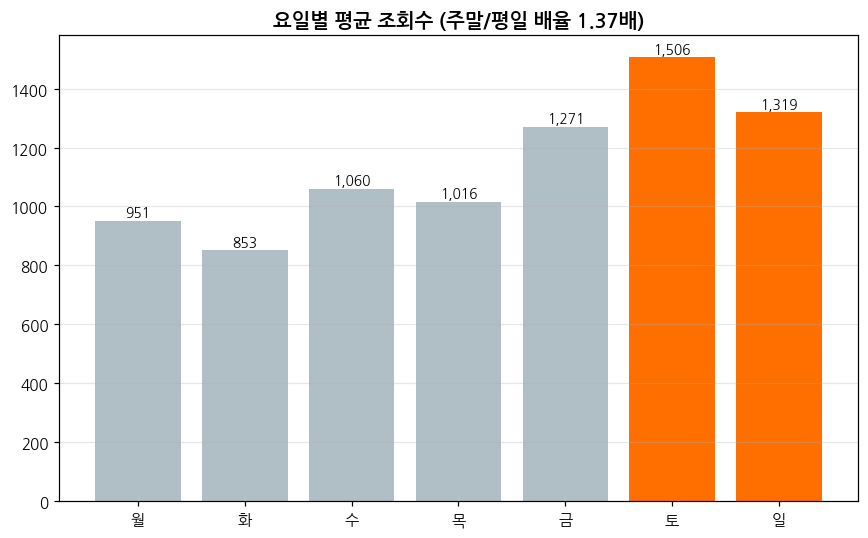

In [6]:
colors = [ORANGE if d in ("토", "일") else "#B0BEC5" for d in wd_order]
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(wd_avg.index, wd_avg.values, color=colors)
for b, v in zip(bars, wd_avg.values):
    ax.text(b.get_x() + b.get_width()/2, v + 15, f"{v:,.0f}", ha="center", fontsize=9)
ax.set_title(f"요일별 평균 조회수 (주말/평일 배율 {lift:.2f}배)", fontsize=13, fontweight="bold")
ax.grid(axis="y", alpha=0.3); fig.tight_layout()
plt.show()


### 시각화 3 — 카테고리별 트렌딩 (최근 4주 vs 이전 4주)

푸드      -50.0
뷰티       -9.6
팝업       -4.7
패션       24.5
딜리버리     38.0
테크      109.4
스테이     111.0
리빙      138.0
dtype: float64


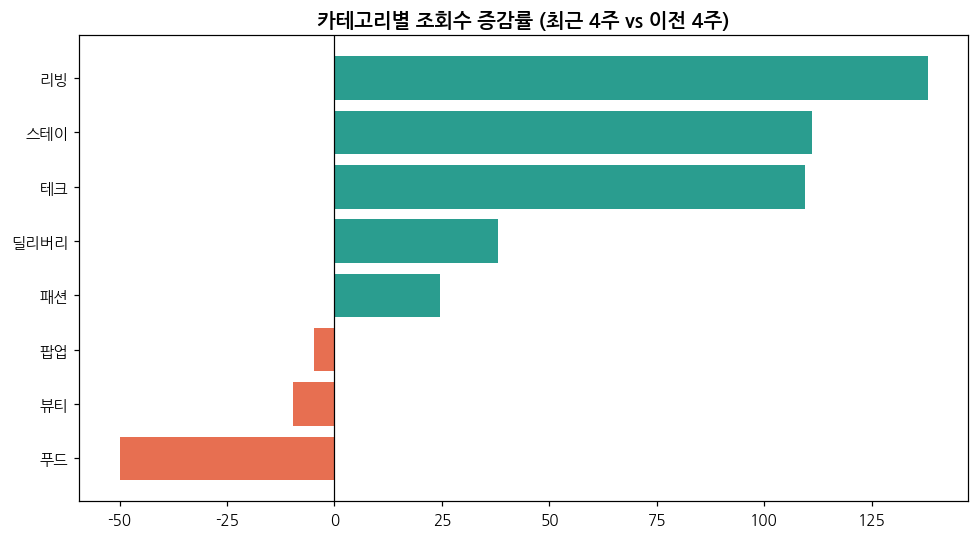

In [7]:
cat_cols = [c for c in df.columns if c.startswith("views_") and c not in ("views_brand", "views_merchant")]
cat_ko = {"views_food":"푸드","views_popup":"팝업","views_beauty":"뷰티","views_fashion":"패션",
          "views_delivery":"딜리버리","views_living":"리빙","views_tech":"테크","views_stay":"스테이"}
df_sorted = df.sort_values("date")
last4 = df_sorted.tail(28)[cat_cols].sum()
prev4 = df_sorted.iloc[-56:-28][cat_cols].sum()
change = ((last4 - prev4) / prev4 * 100).sort_values()
change.index = [cat_ko[c] for c in change.index]
print(change.round(1))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#2A9D8F" if v >= 0 else "#E76F51" for v in change.values]
ax.barh(change.index, change.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("카테고리별 조회수 증감률 (최근 4주 vs 이전 4주)", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


### 시각화 4 — 노벨티 감쇠 곡선

이벤트가 시작된 이후 경과일에 따라 이벤트 1건당 평균 조회수가 어떻게 줄어드는지 측정한다.

0일차 대비 10일차 조회수 비율: 46.0%


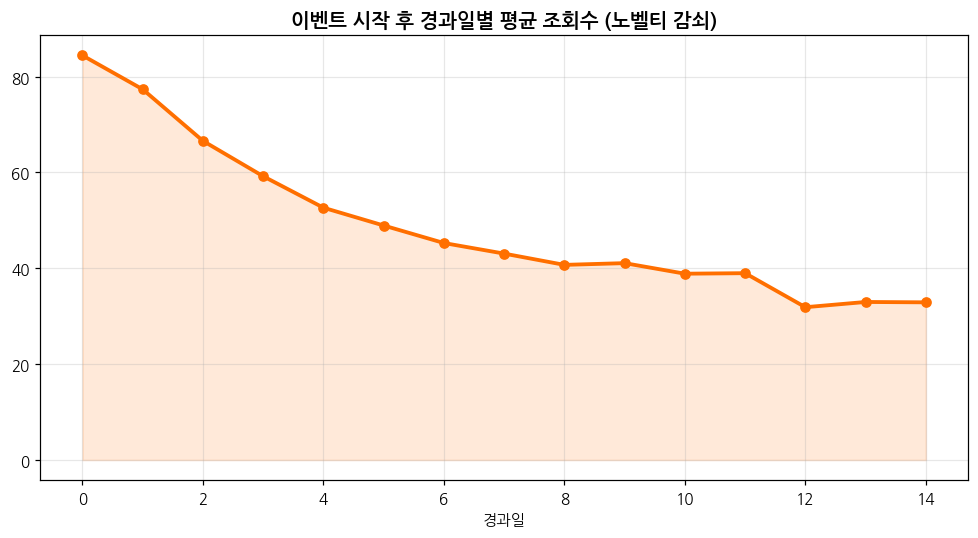

In [8]:
eng = pd.read_csv("data/eventhub_event_daily_engagement.csv", parse_dates=["date"])
eng = eng.merge(events[["id", "period_start"]], left_on="event_id", right_on="id", how="left")
eng["days_since_start"] = (eng["date"] - eng["period_start"]).dt.days
decay = eng[eng.days_since_start.between(0, 14)].groupby("days_since_start")["views"].mean()
print(f"0일차 대비 10일차 조회수 비율: {decay.loc[10]/decay.loc[0]:.1%}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(decay.index, decay.values, marker="o", color=ORANGE, linewidth=2.5)
ax.fill_between(decay.index, decay.values, alpha=0.15, color=ORANGE)
ax.set_title("이벤트 시작 후 경과일별 평균 조회수 (노벨티 감쇠)", fontsize=13, fontweight="bold")
ax.set_xlabel("경과일"); ax.grid(alpha=0.3); fig.tight_layout()
plt.show()


### 시각화 5 — 카테고리별 평균 별점 (리뷰 데이터)

             mean  count
category_ko             
스테이          4.58     24
푸드           4.28     64
리빙           4.24     41
뷰티           4.15     41
패션           4.13     39
테크           4.11     27
딜리버리         4.09     33
팝업           4.00     40


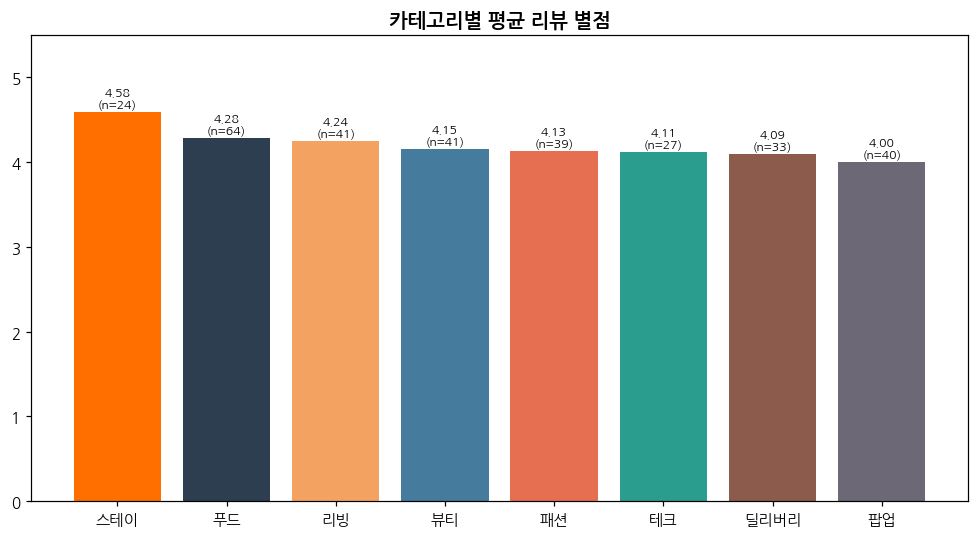


7일 이동평균 조회수 vs 7일 가중평균 별점 상관계수: -0.101 (거의 무상관)


In [9]:
rating_by_cat = reviews.groupby("category_ko")["rating"].agg(["mean", "count"]).sort_values("mean", ascending=False)
print(rating_by_cat.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(rating_by_cat.index, rating_by_cat["mean"], color=PALETTE[:len(rating_by_cat)])
for b, (m, c) in zip(bars, zip(rating_by_cat["mean"], rating_by_cat["count"])):
    ax.text(b.get_x()+b.get_width()/2, m+0.05, f"{m:.2f}\n(n={int(c)})", ha="center", fontsize=8)
ax.set_ylim(0, 5.5)
ax.set_title("카테고리별 평균 리뷰 별점", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

corr = df[["ma7_views", "avg_rating_7d"]].corr().iloc[0, 1]
print(f"\n7일 이동평균 조회수 vs 7일 가중평균 별점 상관계수: {corr:.3f} (거의 무상관)")


## 6. [보너스 A] 시계열 분해 — 추세/계절성/잔차

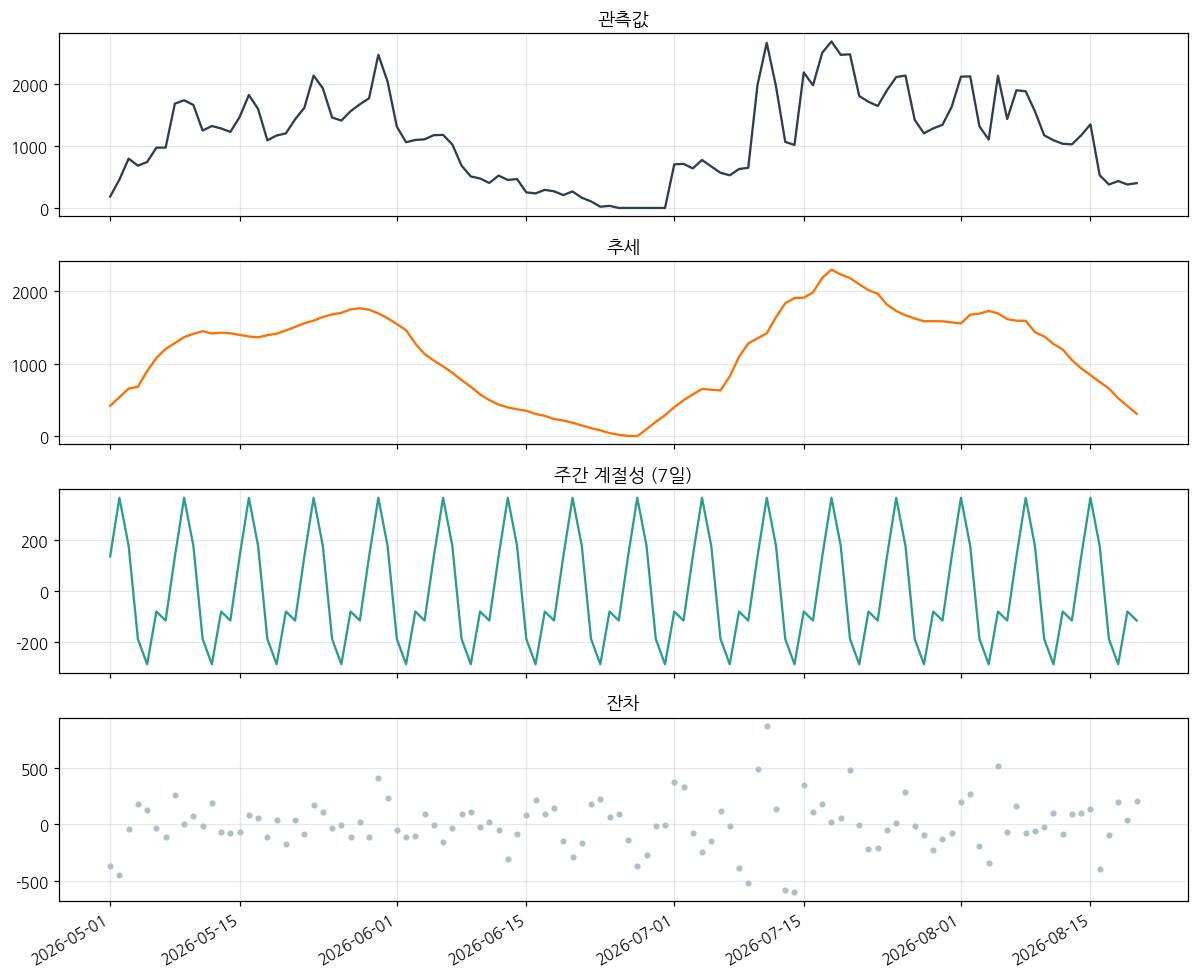

주간 계절성 진폭(최대-최소): 652.1
잔차 표준편차: 225.9  (관측값 평균 대비 19.8%)


In [10]:
ts = df.set_index("date")["total_views"]
decomp = seasonal_decompose(ts, model="additive", period=7, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(11, 9), sharex=True)
axes[0].plot(ts.index, decomp.observed, color="#2C3E50"); axes[0].set_title("관측값")
axes[1].plot(ts.index, decomp.trend, color=ORANGE); axes[1].set_title("추세")
axes[2].plot(ts.index, decomp.seasonal, color="#2A9D8F"); axes[2].set_title("주간 계절성 (7일)")
axes[3].plot(ts.index, decomp.resid, color="#B0BEC5", marker=".", linestyle="none"); axes[3].set_title("잔차")
for a in axes: a.grid(alpha=0.3)
fig.autofmt_xdate(); fig.tight_layout()
plt.show()

print(f"주간 계절성 진폭(최대-최소): {decomp.seasonal.max()-decomp.seasonal.min():.1f}")
print(f"잔차 표준편차: {decomp.resid.std():.1f}  (관측값 평균 대비 {decomp.resid.std()/ts.mean():.1%})")


## 7. [보너스 B] 베이스라인 예측 (Seasonal-Naive)

정확도 자체보다 **가정과 한계**에 집중한다. "지난주 같은 요일 값을 그대로 이번 주 예측치로 사용"하는
가장 단순한 계절성 베이스라인(Seasonal-Naive)을 최근 14일 테스트 구간에 적용한다.

Seasonal-Naive(전주 동요일) MAE = 553.3, MAPE = 86.4%
비교 baseline(전일값 반복) MAE = 197.1


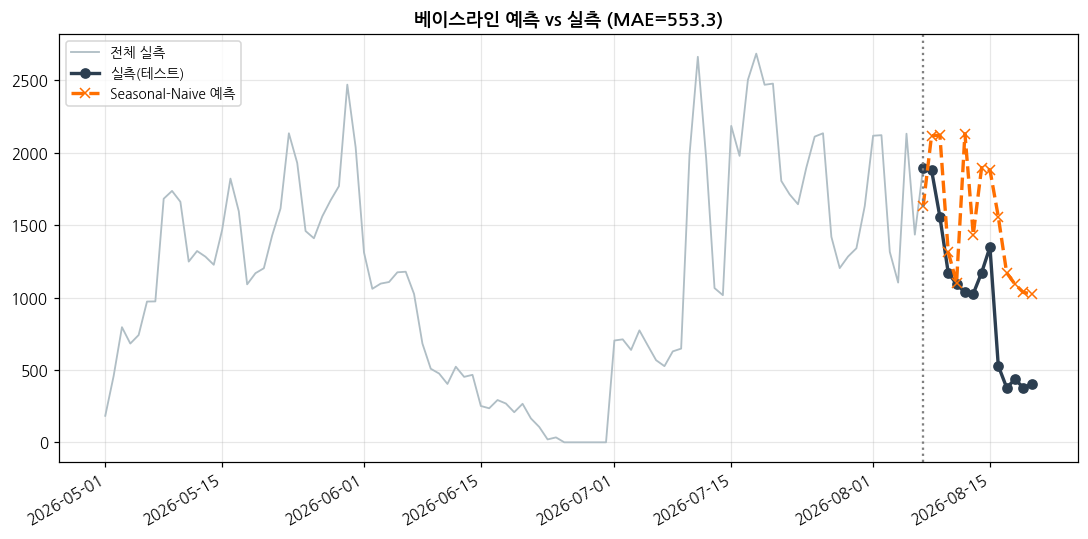

In [11]:
test_days = 14
train, test = ts.iloc[:-test_days], ts.iloc[-test_days:]
pred = ts.shift(7).iloc[-test_days:]

mae = (test - pred).abs().mean()
mape = ((test - pred).abs() / test.replace(0, np.nan)).mean() * 100
naive_prev_day_mae = (test - test.shift(1).fillna(train.iloc[-1])).abs().mean()

print(f"Seasonal-Naive(전주 동요일) MAE = {mae:.1f}, MAPE = {mape:.1f}%")
print(f"비교 baseline(전일값 반복) MAE = {naive_prev_day_mae:.1f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(ts.index, ts.values, color="#B0BEC5", linewidth=1.2, label="전체 실측")
ax.plot(test.index, test.values, color="#2C3E50", linewidth=2.2, marker="o", label="실측(테스트)")
ax.plot(pred.index, pred.values, color=ORANGE, linewidth=2.2, marker="x", linestyle="--", label="Seasonal-Naive 예측")
ax.axvline(test.index[0], color="grey", linestyle=":")
ax.set_title(f"베이스라인 예측 vs 실측 (MAE={mae:.1f})", fontsize=12, fontweight="bold")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.autofmt_xdate(); fig.tight_layout()
plt.show()


**해석(가설)**: Seasonal-Naive가 단순 baseline보다 오히려 MAE가 크다. 원인은 테스트 구간(8/7~8/20)이
카탈로그의 **인위적인 하강 구간**(신규 이벤트가 8/5 이후 더 이상 등록되지 않아 활성 이벤트가 자연 감소)과
겹치기 때문으로 보인다 — 즉 이는 예보 기법 자체의 결함이라기보다, **시드 데이터가 특정 스냅샷 시점 기준의
유한 카탈로그**라는 한계에서 비롯된 구조적 효과다. 실제 서비스처럼 신규 이벤트가 지속적으로 유입된다면
계절성 베이스라인의 성능이 더 안정적일 것으로 예상된다 (결론/한계점 참고).


## 8. 인사이트 (관찰 → 해석 → 액션)

**인사이트 1 — 주말 관심도가 평일 대비 1.37배 높다**
- 관찰(Fact): 주말(토·일) 평균 조회수 1,412 vs 평일 평균 1,030 (배율 1.37배), 특히 토요일이 요일 중 최고치.
- 해석(Why): 할인 이벤트 특성상 여유 시간이 많은 주말에 오프라인 방문/쇼핑 탐색 수요가 몰리는 것으로 추정.
- 행동(Action): 신규 이벤트 노출(푸시 알림, 배너)을 금·토요일 오전에 집중 배치하면 도달률을 높일 수 있다.

**인사이트 2 — '리빙·스테이·테크' 카테고리가 최근 급상승, '푸드'는 급락**
- 관찰(Fact): 최근 4주 vs 이전 4주 비교 시 리빙 +138%, 스테이 +111%, 테크 +109% 증가한 반면 푸드는 -50%.
- 해석(Why): 표본이 카테고리당 20건으로 적어 개별 이벤트 몇 건의 시작/종료 타이밍에 민감하게 반응한 결과일
  가능성이 크다 (통계적 노이즈 포함, 확정적 트렌드로 단정하기엔 표본 부족).
- 행동(Action): 실제 운영 시에는 카테고리당 표본이 커지므로 이 지표를 주간 대시보드로 만들어 브랜드에게
  "지금 뜨는 카테고리" 인사이트로 제공하고, 소상공인 대상 프로모션 슬롯 우선순위에 반영할 수 있다.

**인사이트 3 — 이벤트는 시작 후 10일 내 관심도가 절반 이하로 감쇠한다**
- 관찰(Fact): 0일차 평균 84.4회 조회 → 10일차 38.9회로, 10일 만에 46.1% 수준까지 하락.
- 해석(Why): '한정 기간' 할인의 신선함 효과가 초반에 집중되고 이후 정보가 피드에서 밀려나기 때문으로 추정.
- 행동(Action): 이벤트 중반(5~7일차)에 리마인드 알림·재노출을 넣으면 감쇠 곡선을 완만하게 만들 수 있다.

**인사이트 4 — 이벤트 공급에 6일간의 '공백기'가 존재했다 (실제 카탈로그 기반 발견)**
- 관찰(Fact): 2026-06-25~06-30 6일 동안 활성 이벤트가 0건이었다 (조회수도 0).
- 해석(Why): 5월 초에 시작된 1차 이벤트 물량이 모두 종료된 뒤 다음 물량이 준비되기 전 공급 갭이 발생.
- 행동(Action): 이벤트 소싱 파이프라인에 '진행 중 이벤트 0건 예상일' 사전 경보를 넣어 콘텐츠 공백을 막아야 한다
  — 이는 시뮬레이션이 아니라 **실제 카탈로그 데이터에서 나온 발견**이라는 점에서 특히 실행 가치가 크다.

**인사이트 5 — 조회수(관심도)와 만족도(평점)는 뚜렷한 상관관계가 없다**
- 관찰(Fact): 7일 이동평균 조회수와 7일 가중평균 별점의 상관계수 ≈ -0.10 (사실상 무상관).
- 해석(Why): '많이 보는 이벤트'와 '만족스러운 이벤트'는 서로 다른 축이다 — 관심(조회)은 노출/할인율에,
  만족(평점)은 실제 경험 품질에 좌우되는 것으로 보인다.
- 행동(Action): 랭킹 알고리즘을 조회수 단일 지표가 아니라 조회수×평점 가중치로 설계하면 '인기는 많지만
  실망스러운' 이벤트가 상단에 노출되는 문제를 예방할 수 있다.


## 9. 결론 및 한계점

**결론**: EventHub 이벤트 카탈로그를 기반으로 한 관심도 시뮬레이션에서 주말 성수기 패턴, 이벤트 노벨티
감쇠, 카테고리별 트렌드 로테이션이라는 세 가지 뚜렷한 시계열 구조를 확인했다. 이 구조를 실제 서비스
오픈 후 관측 데이터로 재현·검증할 수 있다면, "지금 뜨는 이벤트/카테고리"를 브랜드·소상공인에게 제공하는
EventHub의 핵심 인사이트 상품(실시간 인기 랭킹)의 데이터 기반을 마련할 수 있다.

**한계점**:
1. 조회수·좋아요·리뷰는 **실제 운영 데이터가 아닌 시뮬레이션**이다. 카테고리 가중치·요일 계수 등은
   합리적 가정이지 실측값이 아니므로, 절대 수치보다는 **패턴(구조)** 을 참고용으로만 해석해야 한다.
2. 분석 기간이 112일(약 16주)로 짧아 월별 계절성이나 장기 추세를 판단하기엔 데이터가 부족하다.
3. 카탈로그 자체가 특정 시점 스냅샷이라 후반부에 신규 이벤트가 끊기는 인공적 하강 구간이 존재해
   예측 성능 평가(6절)를 왜곡할 수 있다.
4. 카테고리별 표본이 20건으로 적어, 트렌드 증감률(인사이트 2)은 노이즈에 민감하다.
5. 소상공인 이벤트 비중이 13.75%로 낮아, 4면 플랫폼 중 '소상공인 지원' 축의 데이터가 상대적으로 얇다.


## 10. AI 사용 로그

- **사용 작업**: (1) 원본 JSON → 일별 시계열 변환 코드 초안 작성, (2) 시뮬레이션 파라미터 설계 및
  검증용 EDA 코드 작성, (3) 8종 시각화 스타일링 코드, (4) 인사이트 문장 초안 다듬기.
- **사용 이유**: 반복적인 pandas 집계/시각화 보일러플레이트 작성 시간 절감, 시계열 분해·예측 baseline
  구현 시 statsmodels API 사용법 확인(대안 탐색).
- **검증 방법**: (a) 생성된 코드는 전부 직접 실행해 수치를 눈으로 재확인(예: 활성 이벤트 0건 구간을
  원본 카탈로그와 대조), (b) `rating_sentiment`(별점 기반)와 `text_sentiment`(키워드 기반) 두 가지 방식으로
  감정 라벨을 이중 산출해 일치율(88.3%)을 교차 검증, (c) 시뮬레이션 결과의 요약 통계(평균/분산/상관계수)가
  설계한 가정과 방향이 일치하는지 재확인.
